# 4. Can We Predict Who's a Strong Problem-Solver?
### Teaching a computer to guess from eye movements alone

---

**How to read this notebook:** Plain text throughout, with a couple of "run this" boxes. No editing needed.

---

## From "there's a pattern" to "can we use it"

Notebook 3 showed that High- and Low-performing students really do look at the correct spot differently. The next question: if you gave a computer *only* someone's eye-movement measurements — never told it whether they got the puzzles right — **could it correctly guess whether they were a strong or weak performer?**

This is exactly the kind of task machine learning is built for: a program that looks at many past examples (in this case, all 130 students' eye-movement measurements *and* their actual performance) and learns which patterns tend to go together, so it can make an educated guess about a case it's never seen before.

We tried five different learning methods and compared how well each one guessed correctly. The simplest one — called Logistic Regression, which essentially learns "add up evidence for and against, see which side wins" — did the best job.

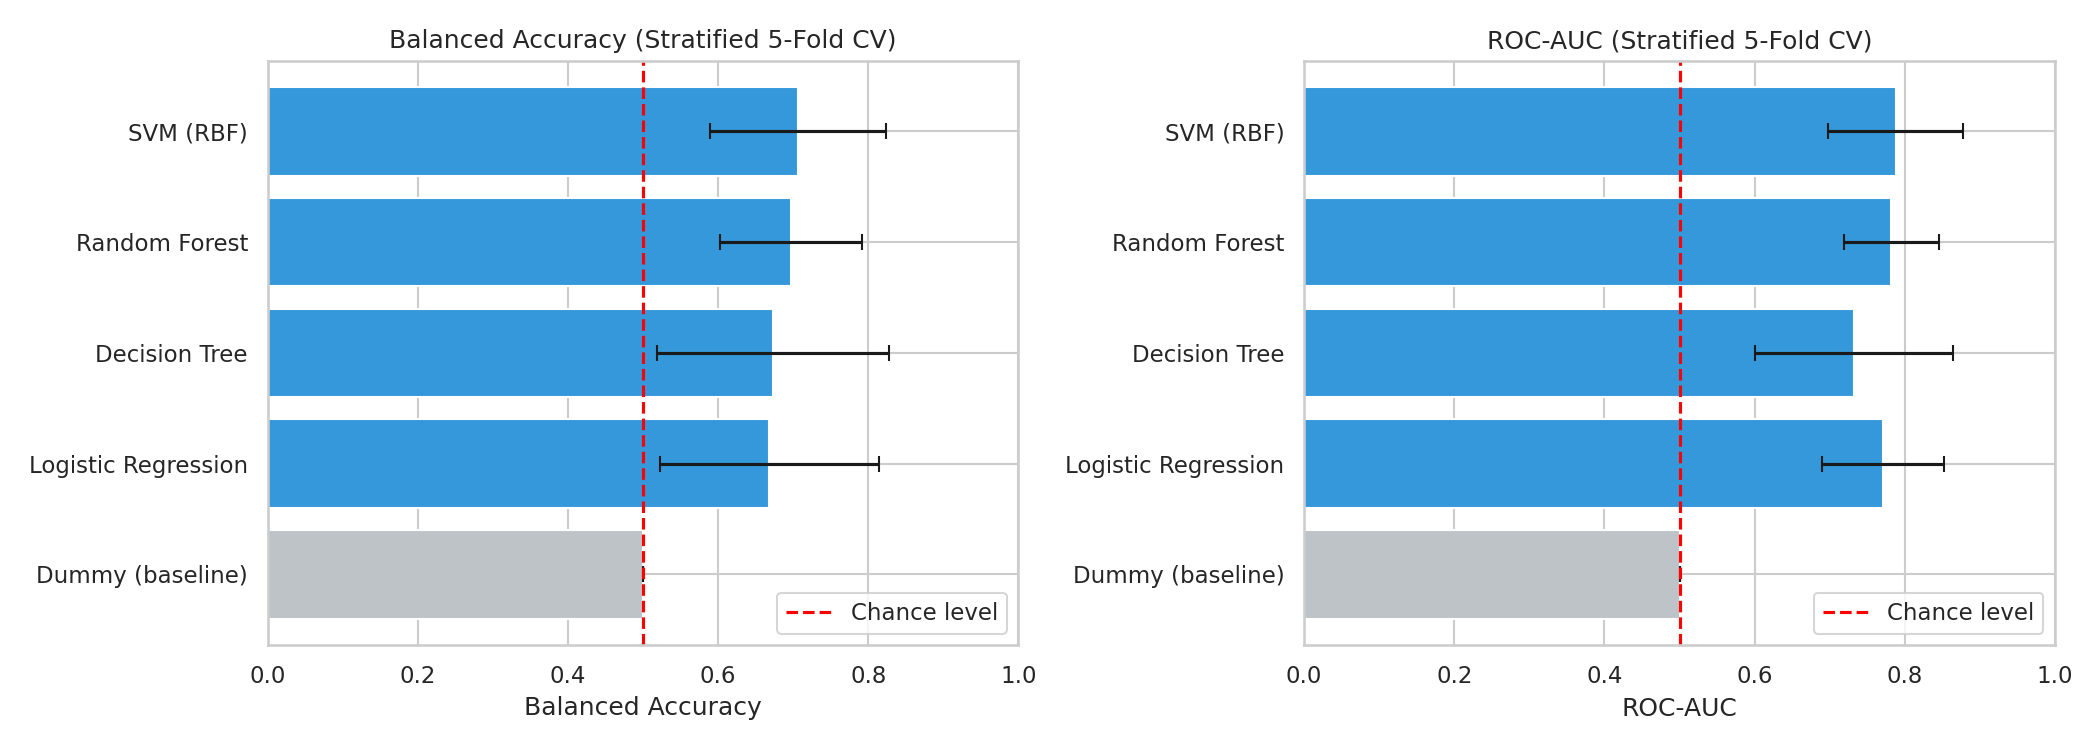

In [1]:
# Run this cell to compare how well 5 different methods guessed correctly
from IPython.display import Image
Image(filename='../outputs/figures/06_model_comparison.png')

## The headline result

To fairly test the program, we used a technique called **cross-validation**: split the 130 students into 5 groups, train on 4 of the groups, test on the 1 group held back, and repeat 5 times so every student gets a turn as the "unseen test." Averaged across all 5 rounds:

> **The program correctly identified whether a student was High- or Low-performing about 4 times out of 5 (80.5% accuracy, balancing both groups fairly).**

## Was that just a lucky guess?

An 80% guess rate sounds good, but *any* pattern-finding program can look impressive by accident if you don't check it properly. So we ran a stress test: **shuffle which student got which actual result completely at random, 1,000 times**, and see how often the program manages to "guess" that well purely by chance.

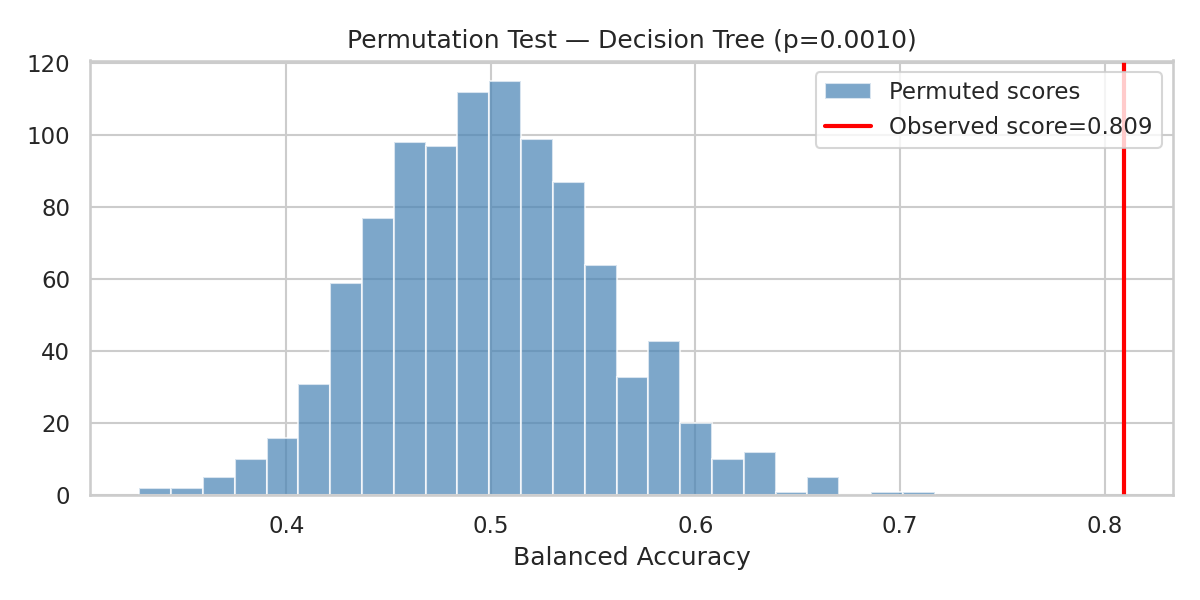

In [2]:
# Run this cell to see the result of shuffling the answers 1,000 times
from IPython.display import Image
Image(filename='../outputs/figures/06_permutation_test.png')

The red line (the program's real, honest performance) sits far to the right of where the shuffled/random attempts (blue bars) landed. Out of 1,000 random shuffles, essentially none did as well as the real pattern — only about **1 in 1,000**. That's strong evidence this is a genuine, learnable pattern, not a statistical fluke.

## What clue did the computer rely on most?

Modern tools can peek inside a trained model and ask, for each individual student, *"which piece of evidence mattered most for this particular guess?"* Here's a real example — a student who genuinely was a High-performer, and was correctly identified as one:

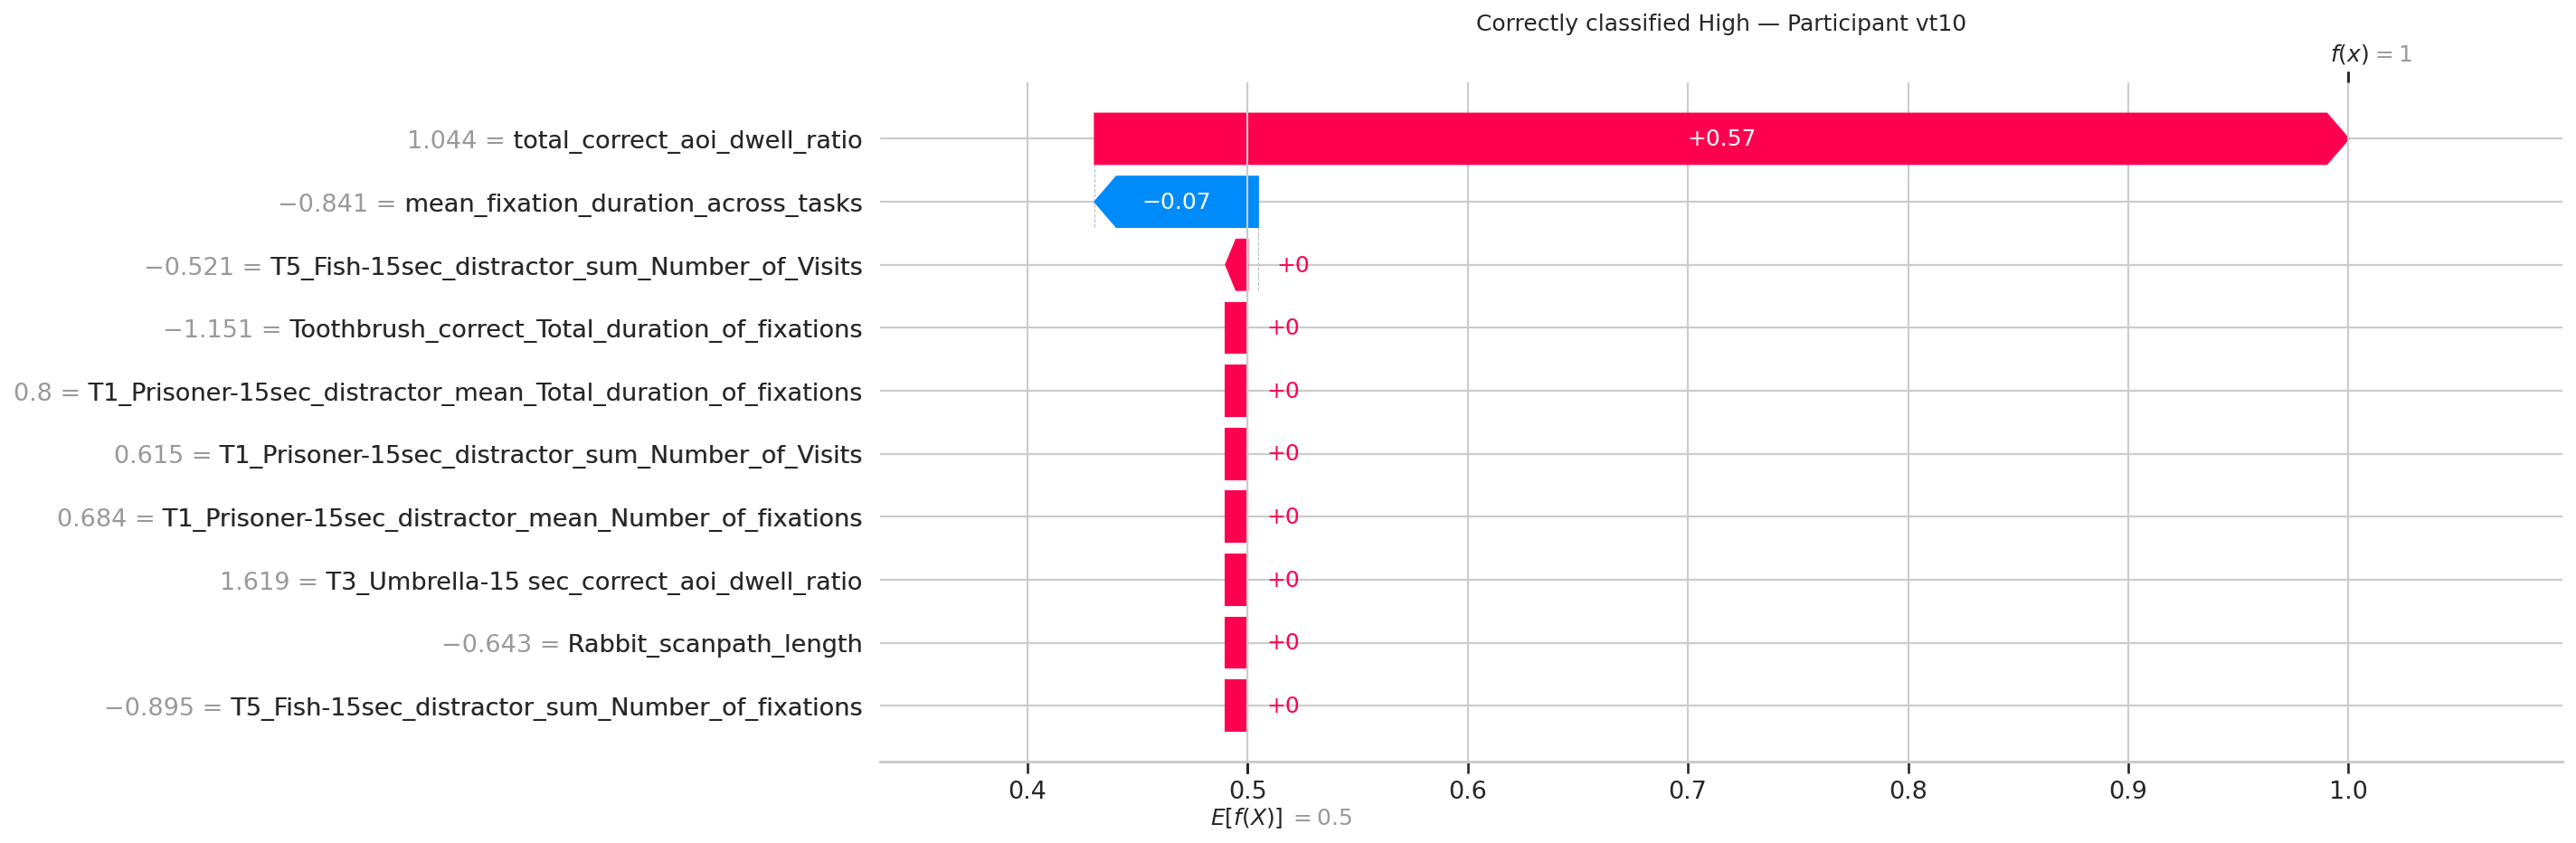

In [3]:
# Run this cell to see a "detective story" for one real student
from IPython.display import Image
Image(filename='../outputs/figures/07_shap_waterfall_Correctly_classified_High.png')

Reading this chart like a detective's case file: the program starts from a neutral baseline (top right label, "E[f(X)]"), then each row is a piece of evidence, pushing the final guess up (pink, toward "High-performer") or down (blue, toward "Low-performer"). For this student, by far the biggest piece of evidence was **how much of their time they spent looking at the correct spot** — exactly the pattern discovered in Notebook 3.

Across all 130 students, that same single clue — **time spent looking at the correct spot** — was the single most important piece of evidence for **6 out of every 10 students**. That's a strong, consistent signal, but it also means the other 4 out of 10 students were correctly (or incorrectly) identified based on subtler, secondary clues.

## Being honest about the limits

No prediction is perfect, and it's important to say plainly where this one falls short:

- The program is noticeably **better at correctly spotting struggling students than at spotting strong ones**. On a completely held-back test group it never used during training, it correctly caught **every single struggling student**, but **missed about 4 in 10 actual strong performers** (mistakenly calling them "struggling").
- The program leans heavily on **one dominant clue** (dwell time on the correct spot). That's a strength when a student's behaviour fits the typical pattern — but it means a student who succeeds through a different, less typical search style is more likely to be misjudged.
- This is a **pattern found in one group of 130 students on one occasion**. It shows a real, statistically solid relationship between eye movements and performance — but it should be treated as a research finding to investigate further, not as a ready-made tool for labelling real students.

## Where to go from here

This notebook series covered the same ground as the full technical analysis, in plain language. If you're curious about the underlying numbers, statistics, and code:

- **`outputs/reports/07_interpretation_report.md`** — the full technical write-up these plain-language summaries were drawn from
- **`notebooks/`** — the complete, code-based analysis pipeline (data cleaning → feature extraction → statistics → machine learning → interpretation)

Thank you for reading — we hope this made a fairly technical piece of cognitive-science research a little more approachable!